#### Imports & Setups

In [1]:
import os
import json
import uuid
import yaml
from pathlib import Path
from rich.json import JSON
from typing import TypedDict
from dotenv import load_dotenv
from langgraph_utils import console
from pydantic import BaseModel, Field
from IPython.display import clear_output
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

params_config = yaml.safe_load(Path("./configs/params.yaml").read_text())
prompts_config = yaml.safe_load(Path("./configs/prompts.yaml").read_text())
load_dotenv()

True

#### Model

In [2]:
model = ChatGoogleGenerativeAI(**params_config["llm"])

#### State

In [3]:
class JokeState(TypedDict):
    character: str
    topic: str
    joke: str
    explanation: str

#### Output Schemas

In [4]:
class JokeSchema(BaseModel):
    joke: str = Field(description=params_config["JokeSchema"]["description"])


class ExplanationSchema(BaseModel):
    explanation: str = Field(description=params_config["ExplanationSchema"]["description"])

#### Node Functions

In [5]:
def generate_joke(state: JokeState):
    joke_prompt = ChatPromptTemplate(
        [
            ("system", prompts_config["generate_joke"]["system_prompt"]),
            ("user", prompts_config["generate_joke"]["user_prompt"]),
        ]
    )

    joke_model = model.with_structured_output(JokeSchema)
    chain = joke_prompt | joke_model

    with console.status("Generate Joke...", spinner="dots"):
        res = chain.invoke(
            {
                "character": state["character"],
                "topic": state["topic"],
            }
        )
    clear_output(wait=True)
    return {"joke": res.joke}


def generate_explanation(state: JokeState):
    explanation_prompt = ChatPromptTemplate(
        [
            ("system", prompts_config["generate_explanation"]["system_prompt"]),
            ("user", prompts_config["generate_explanation"]["user_prompt"]),
        ]
    )

    explanation_model = model.with_structured_output(ExplanationSchema)
    chain = explanation_prompt | explanation_model

    with console.status("Generate Explanation...", spinner="dots"):
        res = chain.invoke(
            {
                "character": state["character"],
                "topic": state["topic"],
                "joke": state["joke"],
            }
        )
    clear_output(wait=False)
    console.print("Workflow executed successfully!")
    return {"explanation": res.explanation}

#### Init Graph

In [6]:
graph = StateGraph(JokeState)


#### Add Nodes

In [7]:
graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

#### Add Edges

In [8]:
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

#### Compilation

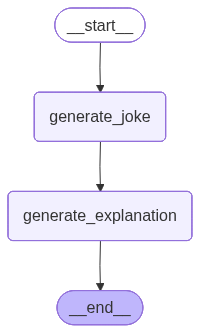

In [9]:
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

#### Config

In [10]:
sirius_id = uuid.uuid1().int

sirius_config = {
    "configurable": {
        "thread_id": sirius_id,
    },
}
console.print(sirius_config)

{'configurable': {'thread_id': 132219138174042729540485014118556777660}}


#### Execution

In [11]:
sirius_config = {"configurable": {"thread_id": "sirius"}}
final_state = workflow.invoke(
    {
        "character": "Shashi Tharoor",
        "topic": "sirius",
    },
    config=sirius_config,
)
console.print_json(data=final_state)

Workflow executed successfully!
{
  "character": "Shashi Tharoor",
  "topic": "sirius",
  "joke": "One might argue that Sirius, being the most resplendent star in our nocturnal panorama, harbors a rather incandescent ego, constantly demanding all available cosmological attention. One does wonder if its formidable brilliance merely stems from an insatiable desire to be the 'goodest boy' of the entire celestial kennel.",
  "explanation": "The joke's setup establishes Shashi Tharoor's verbose, sophisticated style by describing Sirius as the 'most resplendent star' with an 'incandescent ego,' using his famously elaborate vocabulary. The punchline delivers a classic Tharoorian twist, anthropomorphizing the star into a dog. The humor stems from the juxtaposition of cosmic grandiosity with the quaint, internet-era slang 'goodest boy,' typically used for an obedient pet. The 'celestial kennel' extends this absurd metaphor. The humor style is a blend of ironic exaggeration and wordplay, as he a

In [12]:
state_history = list(workflow.get_state_history(sirius_config))
console.print(state_history)

[
    StateSnapshot(
        values={
            'character': 'Shashi Tharoor',
            'topic': 'sirius',
            'joke': "One might argue that Sirius, being the most resplendent star in our nocturnal panorama, harbors a 
rather incandescent ego, constantly demanding all available cosmological attention. One does wonder if its formidable 
brilliance merely stems from an insatiable desire to be the 'goodest boy' of the entire celestial kennel.",
            'explanation': "The joke's setup establishes Shashi Tharoor's verbose, sophisticated style by describing 
Sirius as the 'most resplendent star' with an 'incandescent ego,' using his famously elaborate vocabulary. The punchline
delivers a classic Tharoorian twist, anthropomorphizing the star into a dog. The humor stems from the juxtaposition of 
cosmic grandiosity with the quaint, internet-era slang 'goodest boy,' typically used for an obedient pet. The 'celestial
kennel' extends this absurd metaphor. The humor style is a bl

In [ ]:
os.makedirs("files", exist_ok=True)

with open("files/1-presistance_joke.md", "w") as f:
    f.write(f"Joke:\n{final_state['joke']}\n\nExplanation:\n{final_state['explanation']}")


with open("files/1-presistance_state_history.json", "w") as f:
    json.dump(state_history, f, indent=4)